Sub Package


1. Optimizers

In [10]:
#Minimize the function x^2 + x + 2 with BFGS
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def eqn(x):
    return x**2+x+2

mymin = minimize(eqn, 0, method = 'BFGS')
print(mymin)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.75
        x: [-5.000e-01]
      nit: 2
      jac: [ 0.000e+00]
 hess_inv: [[ 5.000e-01]]
     nfev: 8
     njev: 4


In [6]:
mymin.x

array([-0.50000001])

In [7]:
mymin.x[0]

-0.5000000064345924

In [8]:
#Find root of the equation x + cos(x):

from scipy.optimize import root
from math import cos

def eqn(x):
    return x + cos(x)

myroot = root(eqn, 0)
myroot

/tmp/ipykernel_42084/3555463960.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return x + cos(x)


 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-7.391e-01]
  method: hybr
    nfev: 9
    fjac: [[-1.000e+00]]
       r: [-1.674e+00]
     qtf: [-2.668e-13]

In [9]:
myroot.x[0]

-0.7390851332151607

2. Sparce Matrix
   

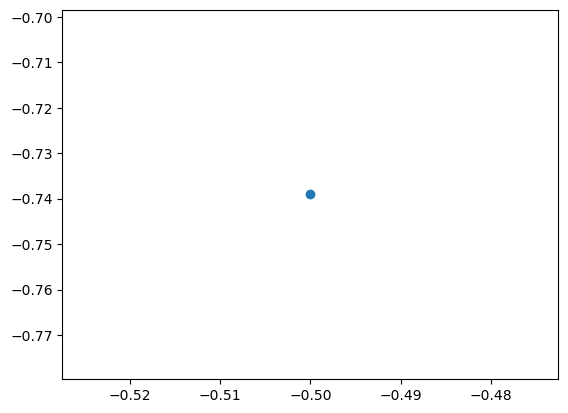

In [16]:
plt.scatter(mymin.x,myroot.x)
plt.show()

2. Sparse Matrix

In [4]:
#Create a CSR matrix from an array:
import numpy as np
from scipy.sparse import csr_matrix 

r = np.array([0,0,0,3,5,3,2,0,3,5])
print(csr_matrix(r))

  (0, 3)	3
  (0, 4)	5
  (0, 5)	3
  (0, 6)	2
  (0, 8)	3
  (0, 9)	5


In [8]:
f = np.array([[3,1,4],[2,3,1],[0,5,6]])

print(csr_matrix(f))

  (0, 0)	3
  (0, 1)	1
  (0, 2)	4
  (1, 0)	2
  (1, 1)	3
  (1, 2)	1
  (2, 1)	5
  (2, 2)	6


In [9]:
print(csr_matrix(f).data)

[3 1 4 2 3 1 5 6]


In [12]:
print(csr_matrix(f).count_nonzero())

8


In [31]:
from scipy.sparse import csr_matrix

d = np.array([[1,5,0,0],[0,3,0,3],[0,4,5,7]])

print(csr_matrix(d).eliminate_zeros())
print(csr_matrix(d).data)

None
[1 5 3 3 4 5 7]


In [34]:
r = np.array([0,0,0,3,5,3,2,0,3,5])
arr = csr_matrix(r).tocsc()
print(arr)


  (0, 3)	3
  (0, 4)	5
  (0, 5)	3
  (0, 6)	2
  (0, 8)	3
  (0, 9)	5


3. Constants

In [35]:
from scipy import constants

print(constants.gram)        #0.001
print(constants.metric_ton)  #1000.0
print(constants.grain)       #6.479891e-05
print(constants.lb)          #0.45359236999999997
print(constants.pound)       #0.45359236999999997
print(constants.oz)          #0.028349523124999998
print(constants.ounce)       #0.028349523124999998
print(constants.stone)       #6.3502931799999995
print(constants.long_ton)    #1016.0469088
print(constants.short_ton)   #907.1847399999999
print(constants.troy_ounce)  #0.031103476799999998
print(constants.troy_pound)  #0.37324172159999996
print(constants.carat)       #0.0002
print(constants.atomic_mass) #1.66053904e-27
print(constants.m_u)         #1.66053904e-27
print(constants.u)           #1.66053904e-27

0.001
1000.0
6.479891e-05
0.45359236999999997
0.45359236999999997
0.028349523124999998
0.028349523124999998
6.3502931799999995
1016.0469088
907.1847399999999
0.031103476799999998
0.37324172159999996
0.0002
1.6605390666e-27
1.6605390666e-27
1.6605390666e-27


4. Spatial Data

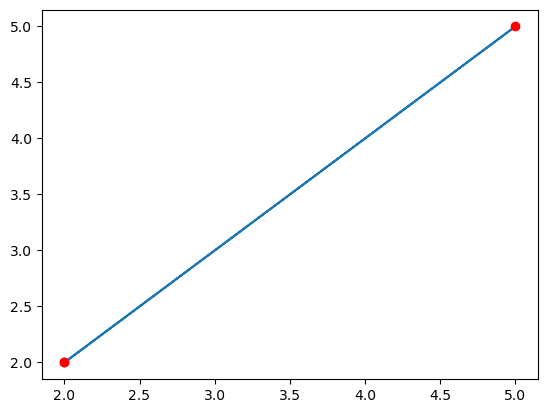

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

r = np.array([[2,5],[5,6],[2,7]])

simplices = Delaunay(r).simplices

plt.triplot(r[:,0],r[:,0] ,simplices)
plt.scatter(r[:,0],r[:,0], c='r')

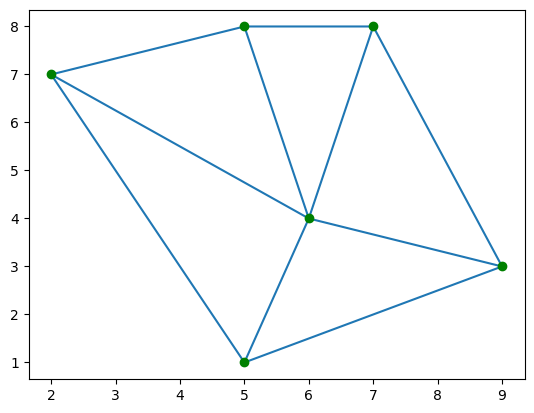

In [43]:
#Create a triangulation from following points:
u = np.array([[2,7],[6,4],[9,3],[5,1],[5,8],[7,8]])

simplices = Delaunay(u).simplices

plt.triplot(u[:,0],u[:,1], simplices)
plt.scatter(u[:,0],u[:,1], c='g')

In [44]:
#Find the hamming distance between given points:

from scipy.spatial.distance import hamming

p1 = (True, False, True)
p2 = (False, True, True)

res = hamming(p1, p2)

print(res)

0.6666666666666666


[]

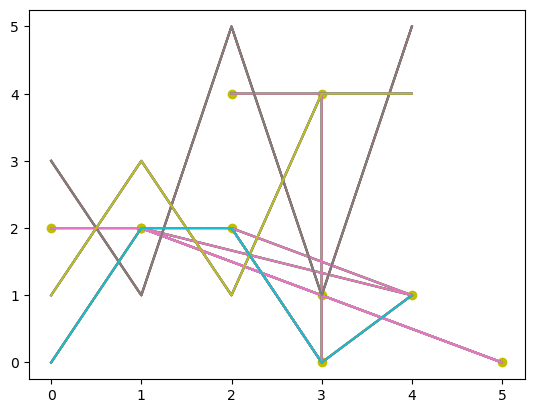

In [47]:
#Create a convex hull for following points:
from scipy.spatial import ConvexHull
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1],
  [1, 2],
  [5, 0],
  [3, 1],
  [1, 2],
  [0, 2]
])

hull = ConvexHull(points)
hull_points = hull.simplices

plt.scatter(points[:,0], points[:,1], c = 'y')

for complex in hull_points:
    plt.plot(points[:,0],points[:,1], simplices)
plt.plot()

[]

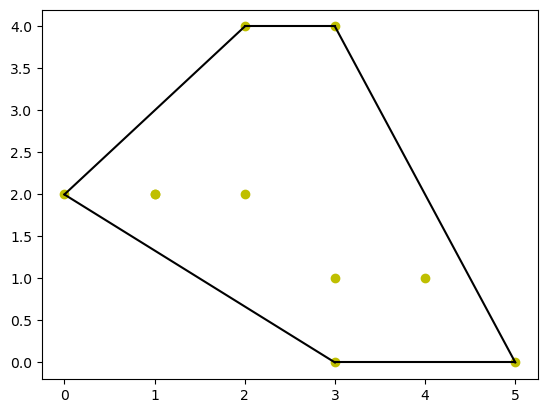

In [50]:
#Create a convex hull for following points:
from scipy.spatial import ConvexHull
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1],
  [1, 2],
  [5, 0],
  [3, 1],
  [1, 2],
  [0, 2]
])

hull = ConvexHull(points)
hull_points = hull.simplices

plt.scatter(points[:,0], points[:,1], c = 'y')

for simplex in hull_points:
    plt.plot(points[simplex,0],points[simplex,1], 'k-')
plt.plot()

5. Interpolation

In [51]:
#Find univariate spline interpolation for 2.1, 2.2... 2.9 for the following non linear points:

from scipy.interpolate import UnivariateSpline
import numpy as np

xs = np.arange(10)
ys = xs**2 + np.sin(xs) + 1

interp_func = UnivariateSpline(xs, ys)

newarr = interp_func(np.arange(2.1, 3, 0.1))

print(newarr)

[5.62826474 6.03987348 6.47131994 6.92265019 7.3939103  7.88514634
 8.39640439 8.92773053 9.47917082]


In [52]:
# For given xs and ys interpolate values from 2.1, 2.2... to 2.9:

from scipy.interpolate import interp1d
import numpy as np

xs = np.arange(10)
ys = 2*xs + 1

interp_func = interp1d(xs, ys)

newarr = interp_func(np.arange(2.1, 3, 0.1))

print(newarr)

[5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8]


6. Graph

In [17]:
# 1.Adjency Matrix
import numpy as np
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

arr = np.array([[4,6,3],[6,8,2],[6,9,3]])

nwar = csr_matrix(arr)
print(connected_components(nwar))
print(nwar.data)

(1, array([0, 0, 0], dtype=int32))
[4 6 3 6 8 2 6 9 3]


In [11]:
from scipy.sparse.csgraph import dijkstra

nwar = csr_matrix(arr)
print(dijkstra(nwar, return_predecessors=True, indices=0) )

(array([0., 6., 3.]), array([-9999,     0,     0], dtype=int32))


In [14]:
from scipy.sparse.csgraph import depth_first_order
arr = np.array([
  [0, 1, 0, 1],
  [1, 1, 1, 1],
  [2, 1, 1, 0],
  [0, 1, 0, 1]
])

newarr = csr_matrix(arr)

print(depth_first_order(newarr, 1))

(array([1, 0, 3, 2], dtype=int32), array([    1, -9999,     1,     0], dtype=int32))


In [15]:
from scipy.sparse.csgraph import breadth_first_order
arr = np.array([
  [0, 1, 0, 1],
  [1, 1, 1, 1],
  [2, 1, 1, 0],
  [0, 1, 0, 1]
])

newarr = csr_matrix(arr)

print(breadth_first_order(newarr, 1))

(array([1, 0, 2, 3], dtype=int32), array([    1, -9999,     1,     1], dtype=int32))


7. Statistics

In [57]:
#Find if the given value follows the normal distribution:

import numpy as np
from scipy.stats import kstest

v = np.random.normal(size=100)

res = kstest(v, 'norm')

print(res)

KstestResult(statistic=0.19533144332078345, pvalue=0.0008103167796739073, statistic_location=-0.34600745334906446, statistic_sign=1)


In [61]:
#Find skewness and kurtosis of values in an array:

import numpy as np
from scipy.stats import skew, kurtosis

v = np.random.normal(size=100)

print(skew(v))
print(kurtosis(v))

0.24589829759760787
-0.24752824684184338


8. Signal Processing

The scipy.signal module in SciPy provides a comprehensive suite of tools for 
digital signal processing, covering various aspects of signal analysis, filtering, and manipulation.

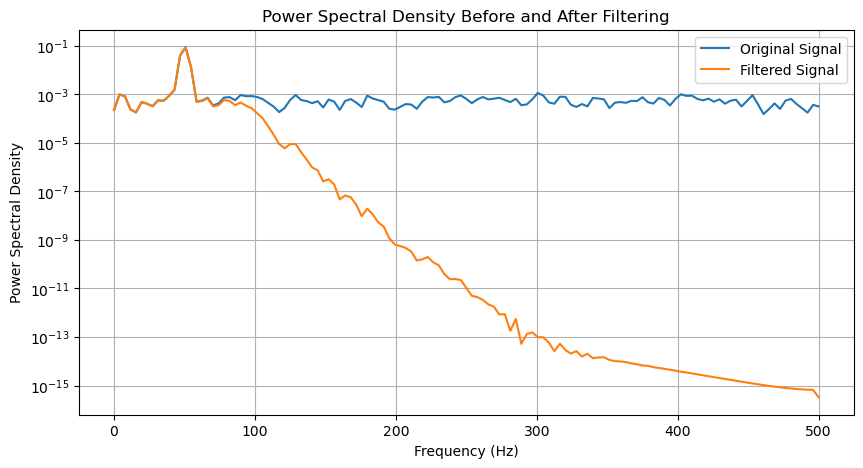

In [2]:
import numpy as np
from scipy.signal import welch, butter, filtfilt
import matplotlib.pyplot as plt

# Parameters
fs = 1000  # Sampling frequency (Hz)
t = np.linspace(0, 1, fs)  # 1 second of data
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.random.randn(len(t))  # 50 Hz sine + noise

# Design a low-pass filter (e.g., cutoff at 100 Hz)
b, a = butter(4, 100 / (fs / 2), btype='low')
filtered_signal = filtfilt(b, a, signal)

# Compute PSDs
f_original, Pxx_original = welch(signal, fs=fs, nperseg=256)
f_filtered, Pxx_filtered = welch(filtered_signal, fs=fs, nperseg=256)

# Plot
plt.figure(figsize=(10, 5))
plt.semilogy(f_original, Pxx_original, label='Original Signal')
plt.semilogy(f_filtered, Pxx_filtered, label='Filtered Signal')
plt.title("Power Spectral Density Before and After Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.legend()
plt.grid()
plt.show()


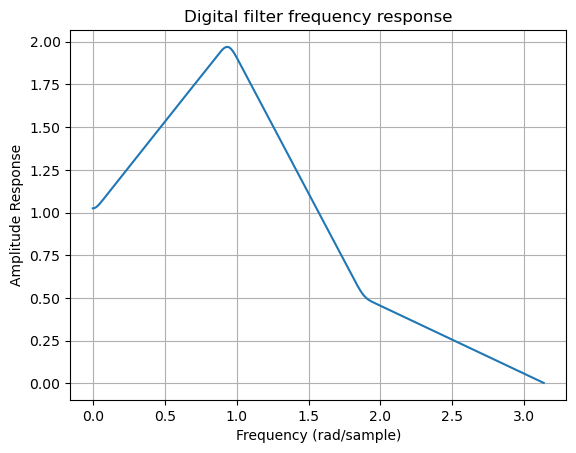

In [3]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
b = signal.firwin2(150, [0.0, 0.3, 0.6, 1.0], [1.0, 2.0, 0.5, 0.0])
w, h = signal.freqz(b)
plt.title('Digital filter frequency response')
plt.plot(w, np.abs(h))
plt.title('Digital filter frequency response')
plt.ylabel('Amplitude Response')
plt.xlabel('Frequency (rad/sample)')
plt.grid()
plt.show()

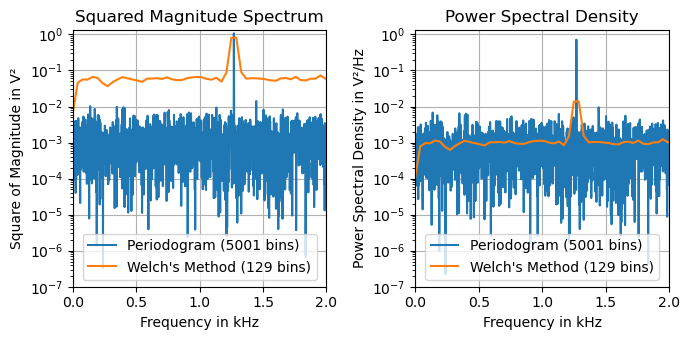

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal

rng = np.random.default_rng(73625)  # seeding for reproducibility

fs, n = 10e3, 10_000
f_x, noise_power = 1270, 1e-3 * fs / 2
t = np.arange(n) / fs
x = (np.sqrt(2) * np.sin(2 * np.pi * f_x * t) +
     rng.normal(scale=np.sqrt(noise_power), size=t.shape))

fg, axx = plt.subplots(1, 2, sharex='all', tight_layout=True, figsize=(7, 3.5))
axx[0].set(title="Squared Magnitude Spectrum", ylabel="Square of Magnitude in V²")
axx[1].set(title="Power Spectral Density", ylabel="Power Spectral Density in V²/Hz")
for ax_, s_ in zip(axx, ('spectrum', 'density')):
    f_p, P_p = signal.periodogram(x, fs, 'hann', scaling=s_)
    f_w, P_w = signal.welch(x, fs, scaling=s_)
    ax_.semilogy(f_p/1e3, P_p, label=f"Periodogram ({len(f_p)} bins)")
    ax_.semilogy(f_w/1e3, P_w, label=f"Welch's Method ({len(f_w)} bins)")
    ax_.set(xlabel="Frequency in kHz", xlim=(0, 2), ylim=(1e-7, 1.3))
    ax_.grid(True)
    ax_.legend(loc='lower center')
plt.show()

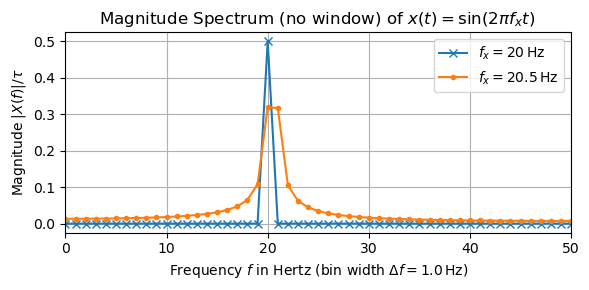

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.fft import rfft, rfftfreq

n, T = 100, 0.01  # number of samples and sampling interval
fcc = (20, 20.5)  # frequencies of sines
t = np.arange(n) * T
xx = (np.sin(2 * np.pi * fx_ * t) for fx_ in fcc)  # sine signals

f = rfftfreq(n, T)  # frequency bins range from 0 Hz to Nyquist freq.
XX = (rfft(x_) / n for x_ in xx)  # one-sided magnitude spectrum

fg1, ax1 = plt.subplots(1, 1, tight_layout=True, figsize=(6., 3.))
ax1.set(title=r"Magnitude Spectrum (no window) of $x(t) = \sin(2\pi f_x t)$ ",
        xlabel=rf"Frequency $f$ in Hertz (bin width $\Delta f = {f[1]}\,$Hz)",
        ylabel=r"Magnitude $|X(f)|/\tau$", xlim=(f[0], f[-1]))
for X_, fc_, m_ in zip(XX, fcc, ('x-', '.-')):
    ax1.plot(f, abs(X_), m_, label=rf"$f_x={fc_}\,$Hz")

ax1.grid(True)
ax1.legend()
plt.show()

9. Image Processing

SciPy, particularly its scipy.ndimage module, provides tools for n-dimensional image processing and analysis in Python. 
While more specialized libraries like scikit-image offer a broader range of image processing functions, scipy.ndimage 
is useful for various tasks, especially when integrated with NumPy for array manipulation.

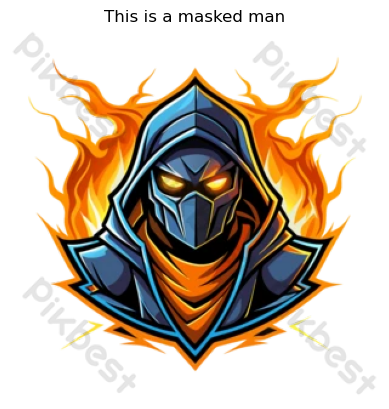

Shape: (305, 305, 4)
Data type: uint8


In [4]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread('masked.png')

plt.imshow(img)
plt.axis('off')
plt.title("This is a masked man")
plt.show()
print("Shape:", img.shape)
print("Data type:", img.dtype)

In [6]:
print("Min:", img.min())
print("Max:", img.max())
print("Mean:", img.mean())

Min: 0
Max: 255
Mean: 75.45918839021769


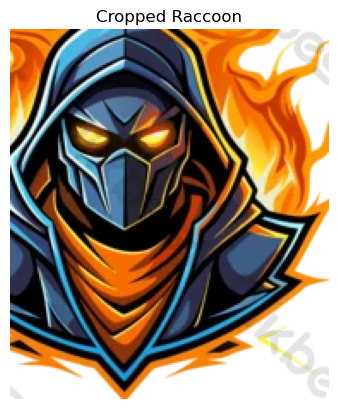

In [14]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

crop = iio.imread("pink.png")
x, y, _ = crop.shape

crop = img[x//3: -x//8, y//3: -y//8]

plt.imshow(crop)
plt.axis('off')
plt.title("Cropped Raccoon")
plt.show()

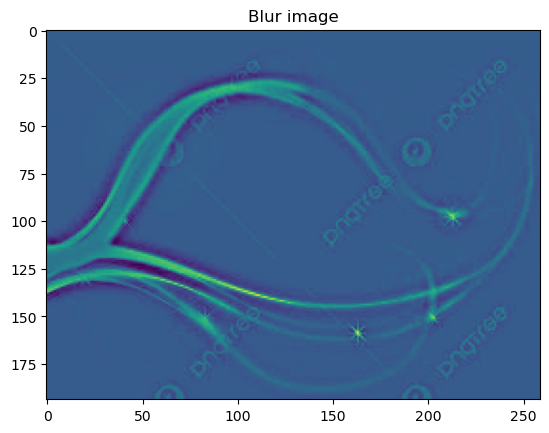

In [33]:
from scipy.ndimage import gaussian_filter
from skimage.color import rgb2gray, rgba2rgb
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread('pink.png')
if img.shape[-1] == 2:
    img = gba2rgb(img)

gray = rgb2gray(img).astype(float)
blur = gaussian_filter(gray, 3)
alpha = 10
sharp = gray + alpha * (gray - gaussian_filter(blur, 1))

plt.imshow(sharp)
plt.axis('on')
plt.title("Blur image")
plt.show()

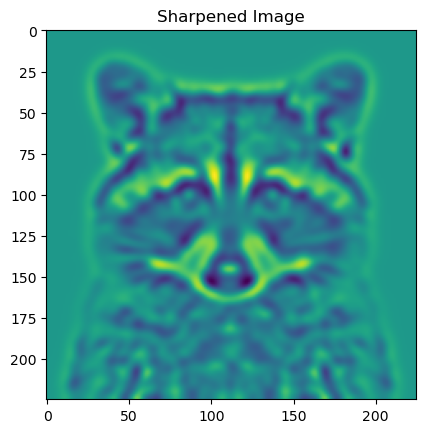

In [28]:
from scipy.ndimage import gaussian_filter
from skimage.color import rgb2gray, rgba2rgb
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread("raccoon.png")
if img.shape[-1]== 4:
   img = rgba2rgb(img)

gray = rgb2gray(img).astype(float)
blur = gaussian_filter(gray,3)
alpha = 40
sharp = blur + alpha*(blur - gaussian_filter(blur,3))

plt.imshow(sharp)
plt.axis('on')
plt.title('Sharpened Image')
plt.show()

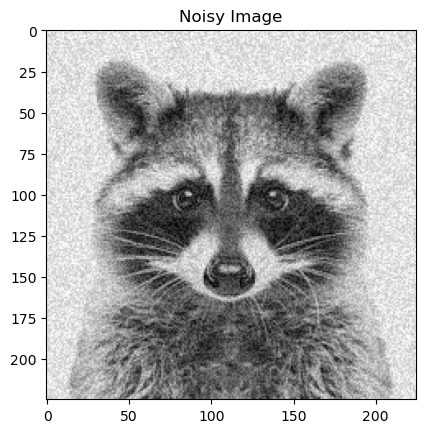

In [32]:
import numpy as np
img = iio.imread('raccoon.png')
if img.shape[-1] == 4:
    img = rgba2rgb(img)
gray = rgb2gray(img).astype(float)
noise_img = gray + 0.9 * gray.std() * np.random.random(gray.shape)

plt.imshow(noise_img, cmap='gray')
plt.axis('on')
plt.title("Noisy Image")
plt.show()

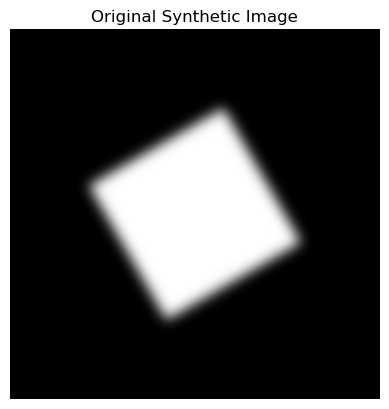

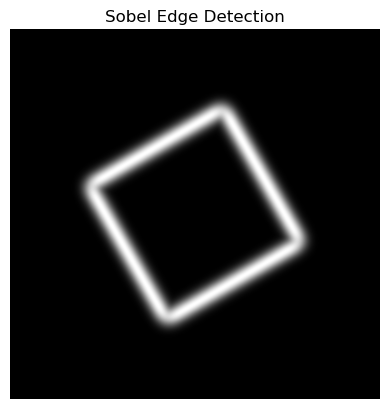

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate, gaussian_filter, sobel

im = np.zeros((300, 300))
im[64:-64, 64:-64] = 1

im = rotate(im, 30, mode='constant')
im = gaussian_filter(im, sigma=7)

plt.imshow(im, cmap='gray')
plt.axis('off')
plt.title("Original Synthetic Image")
plt.show()

dx = sobel(im, axis=0, mode='constant')
dy = sobel(im, axis=1, mode='constant')
sobel_edges = np.hypot(dx, dy)

plt.imshow(sobel_edges, cmap='gray')
plt.axis('off')
plt.title("Sobel Edge Detection")
plt.show()